# Аналіз прямої мови

## Виокремлення фрагментів прямої мови

Кожен окремий діалог буде зберігатися в одному рядку `.txt` файлу. Тобто кожен рядок файлу - це окремий діалог.

In [1]:
import re

import requests
from matplotlib import pyplot as plt

In [2]:
INPUT_FILE = "../lab01/Zabrodin_file_1.txt"
OUTPUT_FILE = "Zabrodin_file_7.txt"

pattern = re.compile(r"^—\s*.*$", flags=re.MULTILINE)

In [3]:
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    text = f.read()

dialogues = [d.group().strip() for d in pattern.finditer(text) if d.group().strip()]

print(f"К-сть діалогів дорівнює {len(dialogues)}.")

for i, d in enumerate(dialogues[:10], 1):
    print(f"[{i:>2}] {d}")

К-сть діалогів дорівнює 929.
[ 1] — Карпе! — промовив Лаврін. — А кого ти будеш оце сватать? Адже ж оце перед Семеном тебе батько, мабуть, оженить.
[ 2] — Посватаю, кого трапиться, — знехотя обізвався Карпо.
[ 3] — Сватай, Карпе, Палажку. Кращої од Палажки нема на всі Семигори.
[ 4] — То сватай, як тобі треба, — сказав Карпо.
[ 5] — Якби на мене, то я б сватав Палажку, — сказав Лаврін. — В Палажки брови, як шнурочки; моргне, ніби вогнем сипне. Одна брова варта вола, другій брові й ціни нема. А що вже гарна! Як намальована!
[ 6] — Коли в Палажки очі витрішкуваті, як у жаби, стан кривий, як у баби.
[ 7] — То сватай Хіврю. Хівря доладна, як писанка.
[ 8] — І вже доладна! Ходить так легенько, наче в ступі горох товче, а як говорить, то носом свистить.
[ 9] — То сватай Вівдю. Чим же Вівдя негарна? Говорить тонісінько, мов сопілка грає, а тиха, як ягниця.
[10] — Тиха, як телиця. Я люблю, щоб дівчина була трохи бриклива, щоб мала серце з перцем, — сказав Карпо.


In [4]:
END = r"[.!?]"
END_OR_COMMA = r"[,!?]"

rules = (
    # — Текст[END]
    re.compile(rf"^—\s*.+({END})$", re.MULTILINE),

    # — Текст[END_OR_COMMA] — слова автора[END]
    re.compile(rf"^—\s*.+({END_OR_COMMA})\s*—\s*[а-щьюяґєії].+({END})$", re.MULTILINE),

    # — Текст[END] — Слова автора[END]
    re.compile(rf"^—\s*.+({END})\s—\s[А-ЩЬЮЯҐЄІЇ].+({END})$", re.MULTILINE),

    # — Текст[END_OR_COMMA] — слова: — продовження[END]
    re.compile(rf"^—\s*.+({END_OR_COMMA})\s*—\s*[а-щьюяґєії].+:\s*—\s*.+({END})$", re.MULTILINE),
)

In [5]:
def validate_dialogues(dialogues: list[str]) -> None:
    valid = []
    invalid = []

    for d in dialogues:
        matched_rule = any(rule.match(d) for rule in rules)

        if matched_rule:
            valid.append(d)
        else:
            invalid.append(d)

    print(f"Правильні: {len(valid)}")
    print(f"Неправильні: {len(invalid)}")

    if invalid:
        for i, d in enumerate(invalid[:10], 1):
            print(f"[{i:>1}] {d}")


validate_dialogues(dialogues)

Правильні: 928
Неправильні: 1
[1] — То ти, дочко, не потурай свекрусі. Адже Мотря не мовчить, то й ти не мовчи:


Серед неправильно сформованих діалогів лише один. На мою думку, тут просто було допущена одруківна і замість ':' мала б бути '.'.

In [6]:
dialogues = [d[:-1] + '.' if d.endswith(':') else d for d in dialogues]

In [7]:
validate_dialogues(dialogues)

Правильні: 929
Неправильні: 0


In [8]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(dialogues))

## Звертання

In [9]:
PUNCT = r"[.!?,;:\-—]"
UA_WORD = r"\b[А-ЩЬЮЯҐЄІЇа-щьюяґєії][а-щьюяґєії'\-]*\b"

pattern = re.compile(rf"(?<={PUNCT})\s*({UA_WORD})\s*(?={PUNCT})", re.MULTILINE)

In [10]:
def find_vocatives(dialogues: list[str]) -> list[str]:
    words = []

    for d in dialogues:
        for m in pattern.finditer(d):
            words.append(m.group(1))
    return list(set(words))


vocatives = list(set(find_vocatives(dialogues)))
print(f"Знайдено потенційних звертань: {len(vocatives)}")
for v in sorted(vocatives):
    print(f"{v}")

Знайдено потенційних звертань: 401
Іване
Ідіть
Їжте
Їй-богу
А
Авжеж
Агапіте
Алипіє
Ану
Ат
Балаш
Балашова
Батюшко
Бач
Бе
Бери
Боже
Брешеш
Біжи
Вас
Верни
Ви
Видно
Вийду
Викупи
Водила
Вставай
Встаньте
Він
Гарна
Гвалт
Гей
Геть
Гляди
Глянь
Гм
Говори
Голубчику
Господи
Грицьку
Дай
Дайте
Дарма
Держи
Добривечір
Добридень
Дома
Дражнись
Еге
Ей
Ет
Жінко
Заскубуть
Звикай
Здається
Здоров
Йди
Йдіть
Кажи
Кажуть
Кайдаш
Кайдашенку
Кайдашихо
Карне
Карпе
Каша
Коли
Лаврін
Лавріне
Лаяли
Лучче
Мабуть
Мамо
Марино
Марусе
Марусю
Мелашка
Мелашко
Мені
Ми
Миколає
Може
Мокрино
Моргуля
Мотре
На
Навчай
Навіщо
Нате
Наш
Нащо
Недобрий
Нема
Нехай
Ну
Ні
О
Овва
Ого-го
Одривай
Одчепись
Одчепіться
Одчини
Ой
Ой-ой
Омелько
Омельку
Он
Опізнилась
Оступіться
От
Ото
Ох-ох
Ох-ох-ох
Оце
П'ятінко-матінко
Палажко
Палажку
Пам'ятай
Параска
Параско
Певно
Пересадиш
Перехрестися
Петре
Побачиш
Погана
Поганяй
Подивись
Покаляєш
Пом'яни
Помаж
Посватаю
Посилай
Правда
При
Прийду
Приходь
Проси
Прощай
Прощайте
Пху
Піди
Підсипай
Радуйся
Робили
Ряту

In [11]:
def analyze(words: list[str]) -> list[dict]:
    text = "\n".join(words)

    try:
        response = requests.post("http://localhost:3000/process", data={
            "data": text,
            "tokenizer": "",
            "tagger": "",
            "parser": "",
        })
        response.raise_for_status()
    except requests.exceptions.ConnectionError:
        raise

    result = []
    seen = set()
    for line in response.json()["result"].split("\n"):
        if not line or line.startswith("#"):
            continue

        fields = line.split("\t")

        if len(fields) < 10:
            continue

        word, lemma, upos, feats = fields[1], fields[2], fields[3], fields[5]

        if upos in ("NOUN", "PROPN") and "Animacy=Anim" in feats and ("Case=Nom" in feats or "Case=Voc" in feats):
            if lemma not in seen:
                seen.add(lemma)
                case = "Nom" if "Case=Nom" in feats else "Voc"
                result.append({"word": word, "lemma": lemma, "case": case})

    return result

In [12]:
results = analyze(vocatives)

OUTPUT_FILE = "Zabrodin_vocatives_full.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for r in results:
        f.write(f"{r['word']} {r['lemma']} {r['case']}\n")
        print(f"{r['word']} {r['lemma']} {r['case']}")

print(f"\n{len(results)} слів")

Овва овва Nom
мамо мама Voc
марандара марандара Nom
діти дитина Nom
Палажко Палажко Nom
Гвалт Гвалт Nom
Марино Марино Nom
сердита сердита Nom
Мелашко Мелашко Nom
Дарма Дарма Nom
Балашова Балашов Nom
матінко матінко Voc
Лавріне Лаврін Voc
княгине княгине Voc
сокиру сокира Voc
сину син Voc
Параско Параско Voc
Брешеш брешеш Nom
матушко матушка Voc
Агапіте Агапіте Nom
дівко дівка Voc
жінко жінка Voc
мати мати Nom
моругий моругий Nom
Мокрино Мокрино Nom
Марусе Марус Voc
Жінко Жінко Voc
коса коса Nom
Алипіє Алипія Nom
Омелько Омелько Nom
діточки діточка Nom
сіра сіра Nom
Батюшко Батюшко Nom
Господи Господь Voc
Мелашка Мелашка Nom
проклятих проклятих Nom
Петре Петре Nom
Кайдаш Кайдаш Nom
Кайдашихо Кайдашиха Voc
Іване Іван Voc
Каша Каша Nom
дочко дочко Voc
Миколає миколати Nom

43 слів


Серед отриманих слів досі є неправильні.

In [15]:
NOT_VOCATIVE = {
    "Овва",
    "Сердита",
    "Дарма",
    "сокиру",
    "моругий",
    "коса",
    "проклятих",
    "Каша",
    "Здоров",
    "Гвалт",
    "Брешеш",
    "солі",
    "Погана",
    "Бери",
    "гвалт",
    "сіра",
    "ховай",
    "батька"
}

filtered = [r for r in results if r["word"] not in NOT_VOCATIVE]

OUTPUT_FILE = "Zabrodin_vocatives_filtered.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for r in filtered:
        f.write(f"{r['word']} {r['lemma']} {r['case']}\n")

print(f"\n{len(filtered)} слів")


33 слів


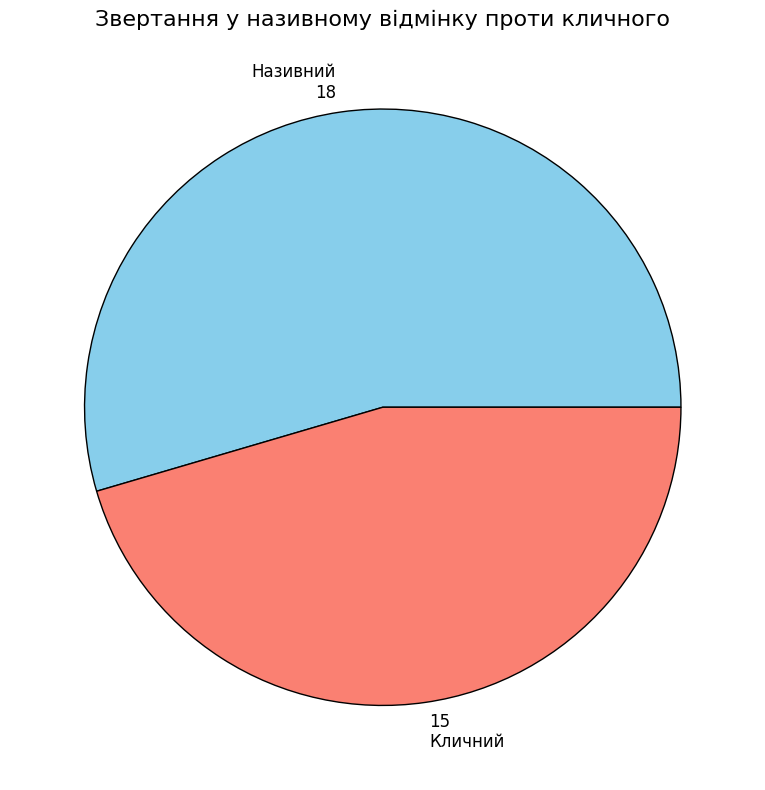

In [16]:
INPUT_FILE = "Zabrodin_vocatives_filtered.txt"
OUTPUT_IMAGE = "Zabrodin_vocatives_pie.png"

nom_count = sum(1 for r in filtered if r["case"] == "Nom")
voc_count = sum(1 for r in filtered if r["case"] == "Voc")

plt.figure(figsize=(8, 8))
plt.pie(
    [nom_count, voc_count],
    labels=[f"Називний\n{nom_count}", f"{voc_count}\nКличний"],
    colors=["skyblue", "salmon"],
    wedgeprops={"edgecolor": "black"},
    textprops={"fontsize": 12},
)

plt.title("Звертання у називному відмінку проти кличного", fontsize=16)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format="png", transparent=True, dpi=300)

plt.show()